In [85]:
import pandas as pd

In [86]:
df_clientes = pd.read_csv('/content/DADOS CLIENTES.csv')
display(df_clientes.head())

,CustomerID,FullName,DOB,Gender,Region,Email,Status,JoinDate
0,1,Norma Fisher,28/02/1977,Female,Florida,thull@yahoo.com,Active,03/08/2023
1,2,Susan Wagner,21/09/1978,Female,California,montgomeryjohn@mcgrath.com,Inactive,19/05/2021
2,3,Stephanie Sutton,03/09/1991,Female,California,ryan93@woods.net,Inactive,29/08/2020
3,4,Ryan Page,04/01/2005,Male,Alaska,vclayton@cross.com,Inactive,02/03/2022
4,5,Daniel Pratt,28/03/1969,Male,Colorado,millerluke@hotmail.com,Suspended,14/09/2024


/tmp/ipykernel_1507/2980853175.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




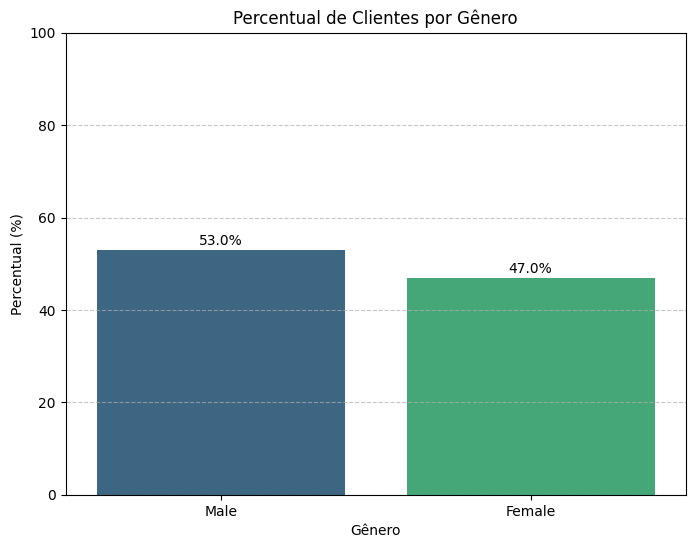

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of clients by gender
gender_counts = df_clientes['Gender'].value_counts(normalize=True) * 100

# Create a DataFrame for plotting
gender_df = gender_counts.reset_index()
gender_df.columns = ['Gender', 'Percentual']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Percentual', data=gender_df, palette='viridis')
plt.title('Percentual de Clientes por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Percentual (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100

# Add percentage labels on top of the bars
for index, row in gender_df.iterrows():
    plt.text(index, row['Percentual'] + 1, f"{row['Percentual']:.1f}%", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [88]:
# Convert 'DOB' to datetime objects, handling potential errors
df_clientes['DOB'] = pd.to_datetime(df_clientes['DOB'], format='%d/%m/%Y', errors='coerce')

# Calculate age based on a reference date (e.g., today's date)
current_date = pd.to_datetime('today')
df_clientes['Age'] = ((current_date - df_clientes['DOB']).dt.days / 365.25).astype(int)

# Drop rows where 'DOB' conversion failed (Age is NaN)
df_clientes.dropna(subset=['Age'], inplace=True)

display(df_clientes[['DOB', 'Age']].head())

,DOB,Age
0,1977-02-28,49
1,1978-09-21,47
2,1991-09-03,34
3,2005-01-04,21
4,1969-03-28,57


### Faixas Etárias

Agora vamos definir as faixas etárias e categorizar os clientes.

In [89]:
# Define age bins and labels
age_bins = [0, 17, 29, 49, 64, df_clientes['Age'].max() + 1] # +1 to ensure max age is included
age_labels = ['<18', '18-29', '30-49', '50-64', '65+']

df_clientes['Age_Group'] = pd.cut(df_clientes['Age'], bins=age_bins, labels=age_labels, right=False)

# Calculate the percentage of clients by age group
age_group_counts = df_clientes['Age_Group'].value_counts(normalize=True) * 100

# Create a DataFrame for plotting
age_group_df = age_group_counts.reset_index()
age_group_df.columns = ['Faixa Etária', 'Percentual']

# Ensure the order of age groups for plotting
age_group_df['Faixa Etária'] = pd.Categorical(age_group_df['Faixa Etária'], categories=age_labels, ordered=True)
age_group_df = age_group_df.sort_values('Faixa Etária')

display(age_group_df)

,Faixa Etária,Percentual
4,<18,0.0
2,18-29,23.0
0,30-49,41.0
1,50-64,31.0
3,65+,5.0


### Gráfico de Percentual de Clientes por Faixa Etária

Vamos visualizar essa distribuição.

/tmp/ipykernel_1507/138706057.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




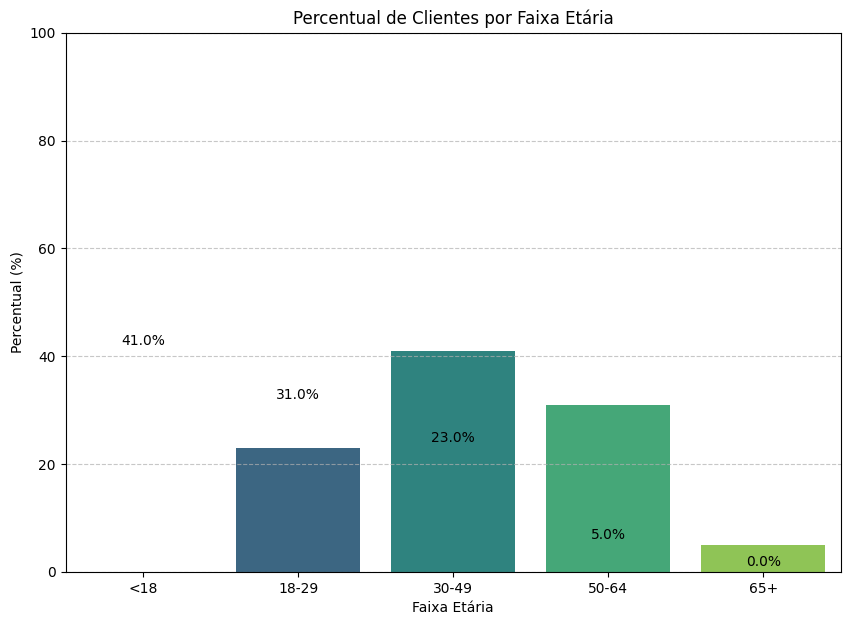

In [90]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Faixa Etária', y='Percentual', data=age_group_df, palette='viridis')
plt.title('Percentual de Clientes por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Percentual (%)')
plt.ylim(0, 100)

# Add percentage labels on top of the bars
for index, row in age_group_df.iterrows():
    plt.text(index, row['Percentual'] + 1, f"{row['Percentual']:.1f}%", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1507/60818633.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




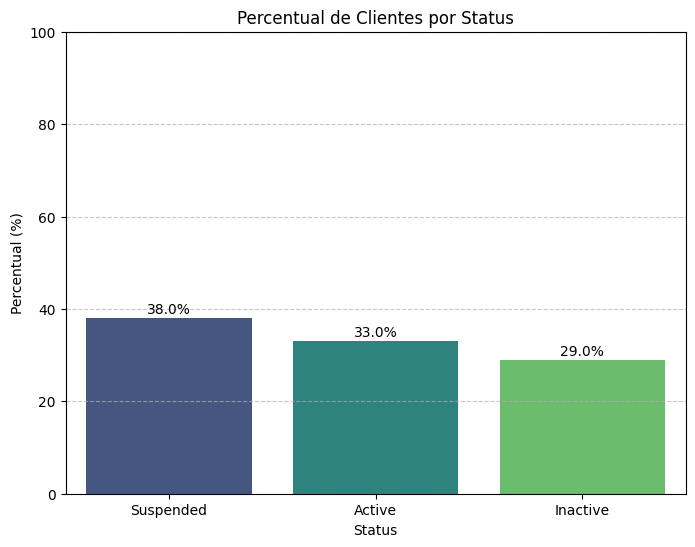

In [91]:
# Calculate the percentage of clients by status
status_counts = df_clientes['Status'].value_counts(normalize=True) * 100

# Create a DataFrame for plotting
status_df = status_counts.reset_index()
status_df.columns = ['Status', 'Percentual']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Status', y='Percentual', data=status_df, palette='viridis')
plt.title('Percentual de Clientes por Status')
plt.xlabel('Status')
plt.ylabel('Percentual (%)')
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100

# Add percentage labels on top of the bars
for index, row in status_df.iterrows():
    plt.text(index, row['Percentual'] + 1, f"{row['Percentual']:.1f}%", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [92]:
# Install plotly for interactive mapping
!pip install plotly
import plotly.express as px
import json

In [93]:
# Count clients per region
region_counts = df_clientes['Region'].value_counts().reset_index()
region_counts.columns = ['State', 'ClientCount']

display(region_counts.head())

,State,ClientCount
0,Massachusetts,19
1,Kansas,18
2,Colorado,16
3,Utah,11
4,California,10


In [94]:
# Load GeoJSON data for US states
# Using a publicly available GeoJSON for US states
# Source: https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_states.json

import requests

url = 'https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_states.json'
response = requests.get(url)
us_states_geojson = json.loads(response.text)

print(f"Loaded GeoJSON for {len(us_states_geojson['features'])} states.")

Loaded GeoJSON for 50 states.


In [95]:
# Install folium for interactive mapping
!pip install folium

In [96]:
import folium

# Create a Folium map centered on the USA
m = folium.Map(location=[39.8283, -98.5795], zoom_start=4)

# Add the choropleth layer
folium.Choropleth(
    geo_data=us_states_geojson,
    name='choropleth',
    data=region_counts,
    columns=['State', 'ClientCount'],
    key_on='feature.properties.name',
    fill_color='Blues', # Changed to a blue color scale
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Número de Clientes por Estado',
    nan_fill_color='lightgrey' # Set color for states with no data
).add_to(m)

folium.LayerControl().add_to(m)

# Display the map
m